In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
from typing import Annotated, Literal, Sequence, TypedDict

In [5]:
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

In [6]:
from pydantic import BaseModel, Field

In [7]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools.retriever import create_retriever_tool

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [8]:
from langgraph.graph import add_messages
from langgraph.prebuilt import tools_condition
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode

In [96]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")

In [97]:
llm.invoke('Hi there!, Who are you?')

AIMessage(content="I'm Llama, a model designed by Meta. I'm here to adapt to your conversational style, whether you need quick answers, deep dives into ideas, or just want to vent, joke or brainstorm. What’s on your mind?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 17, 'total_tokens': 66, 'completion_time': 0.122117178, 'completion_tokens_details': None, 'prompt_time': 0.000429835, 'prompt_tokens_details': None, 'queue_time': 0.777537586, 'total_time': 0.122547013}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_79da0e0073', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d29b4-d39a-7402-a2a1-2e8a46c85397-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 49, 'total_tokens': 66})

In [10]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings=HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [11]:
url='https://lilianweng.github.io/posts/2023-06-23-agent/'

In [12]:
WebBaseLoader(url).load()[0].metadata

{'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/',
 'title': "LLM Powered Autonomous Agents | Lil'Log",
 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\

In [13]:
print(WebBaseLoader(url).load()[0].metadata['description'])

Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.
Agent System Overview
In a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:

Planning

Subgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.
Reflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.


Memory

Short-term memory: I would consider all the in-context learning (See Prompt Engineering) as utilizing short-term memory of the model to learn.
Lon

In [14]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

In [15]:
docs=[WebBaseLoader(url).load() for url in urls]

In [ ]:
docs

In [17]:
len(docs)

3

In [18]:
docs_list=[item for sublist in docs for item in sublist]

In [19]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=100, chunk_overlap=15)

In [20]:
doc_splits=text_splitter.split_documents(docs_list)

In [ ]:
doc_splits

In [22]:
len(doc_splits)

502

In [23]:
vectorstore=Chroma.from_documents(
    documents=doc_splits,
    collection_name='agentic_rag',
    embedding=embeddings
)

In [24]:
retriever=vectorstore.as_retriever()

In [38]:
print(retriever.invoke("what are Memory Types in agents?"))

[Document(metadata={'language': 'en', 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\n\nShort-term memory: I would consider all the in-context learning (See Prompt Engi

In [39]:
retriever_tool=create_retriever_tool(
    retriever,
    "retriever_blog_posts",
    "search and return information about agents, prompt engineering and adversarial attack on LLMs from the blog posts provided"
    )

In [40]:
tools=[retriever_tool]

In [56]:
retrieve=ToolNode([retriever_tool])

In [43]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [98]:
def ai_assistant(state : AgentState):
    print("AI Assistant is processing the request...")
    messages=state['messages']
    llm_with_tools=llm.bind_tools(tools)
    response=llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [99]:
class Grade(BaseModel):
    binary_score: Literal["yes", "no"] = Field(description='Relevance Score "yes" or "no"')

In [100]:
def grade_documents(state : AgentState):
    llm_with_structre_output=llm.with_structured_output(Grade)
    
    prompt=PromptTemplate(
        template="""You are a grader deciding if a document is relavent to a user's question.
        Here is the document: {context}
        Here is the user question: {question}
        If the document talks about or contain information related to the user question, mark it as relevant.
         Give a 'yes' or 'no' answer to show if the document is relevant to the question.""",
        input_variables=["context", "question"]
    )
    
    chain=prompt | llm_with_structre_output
    
    messages=state['messages']
    print(f"Message from the grader: {messages}")
    last_message=messages[-1]
    question=messages[0].content
    docs=last_message.content
    scored_result=chain.invoke({'question': question, 'context': docs})
    score=scored_result.binary_score
    
    if score=='yes':
        print("The document is relevant to the question.")
        return "generator" #this should be a node name
    else:
        print("The document is not relevant to the question.")
        return "rewriter" #this should be a node name

In [89]:
prompt.pretty_print()

================================ Human Message =================================

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:


In [101]:
from langsmith import Client
 
def generate(state : AgentState):
    print("Output Generator is processing the request...")
    
    messages=state['messages']
    print(f"Message from the generator: {messages}")
    
    question=messages[0].content
    last_message=messages[-1]
    docs=last_message.content
    
    client = Client()  
    prompt = client.pull_prompt("rlm/rag-prompt") 
    
    rag_chain=prompt | llm
    response=rag_chain.invoke({'context': docs, 'question': question })
    
    print(f"This is my response: {response}")
    return {'messages': [response]}

In [102]:
from langchain_core.messages import HumanMessage
def rewrite(state : AgentState):
    print("Query Re-Writer is processing the request...")
    messages=state['messages']
    question=messages[0].content
    
    print(f"Here is message from re-writer: {question}")
    
    message=[
        HumanMessage(
            content=f"""
                    You are rewriting a user question to improve document retrieval in a RAG system.
                    try to reason about the underlying semantic meaning intent.

                    Topic: LLM Powered Autonomous Agents, Prompt Engineering, AdversarialAttacks on LLMs.
                    Original Question: {question}

                    Rewrite the question so that it:
                    new question that is semantically similar to the initial question but with different wording.
                    Preserves the original meaning.
                    Uses clear and specific terminology related to the topic.
                    Includes relevant keywords that would help retrieve accurate documents.
                    Is concise and well-formed.

                    Do not add explanations or extra text.
                    Return only the rewritten question.
            """
            )
    ]
    response=llm.invoke(message)
    return {'messages': [response]}

In [103]:
workflow=StateGraph(AgentState)
workflow.add_node('My_AI_Assistant', ai_assistant)
workflow.add_node('Vector_Retriever', retrieve)
workflow.add_node('Output_Generator', generate)
workflow.add_node('Query_Re-Writer', rewrite)

In [104]:
workflow.add_edge(START,"My_AI_Assistant")
workflow.add_conditional_edges(
    "My_AI_Assistant", 
    tools_condition,
    {'tools': 'Vector_Retriever', END:END}
    )

workflow.add_conditional_edges(
    "Vector_Retriever",
    grade_documents,
    {'generator': 'Output_Generator',
     "rewriter": 'Query_Re-Writer'}
)

workflow.add_edge('Output_Generator', END)

workflow.add_edge('Query_Re-Writer', "My_AI_Assistant")

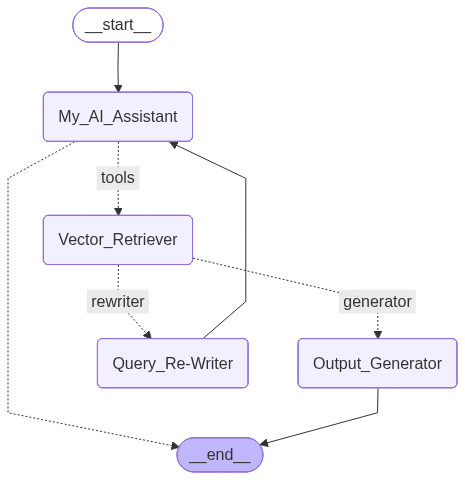

In [105]:
app=workflow.compile()
app

In [74]:
app.invoke({'messages':['What is a Autonomous Agent?']})

AI Assistant is processing the request...
Message from the grader: [HumanMessage(content='What is a Autonomous Agent?', additional_kwargs={}, response_metadata={}, id='41a3b032-659f-4f39-91cb-570e11c545c6'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'qams3q4bn', 'function': {'arguments': '{"query":"Autonomous Agent"}', 'name': 'retriever_blog_posts'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 737, 'total_tokens': 770, 'completion_time': 0.083720609, 'completion_tokens_details': None, 'prompt_time': 0.031141466, 'prompt_tokens_details': None, 'queue_time': 0.044990804, 'total_time': 0.114862075}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_37da608fc1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d299b-2974-7d33-a4b9-075a08794226-0', tool_calls=[{'name': 'retriever_blog_posts', 'args': {'query':

{'messages': [HumanMessage(content='What is a Autonomous Agent?', additional_kwargs={}, response_metadata={}, id='41a3b032-659f-4f39-91cb-570e11c545c6'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'qams3q4bn', 'function': {'arguments': '{"query":"Autonomous Agent"}', 'name': 'retriever_blog_posts'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 737, 'total_tokens': 770, 'completion_time': 0.083720609, 'completion_tokens_details': None, 'prompt_time': 0.031141466, 'prompt_tokens_details': None, 'queue_time': 0.044990804, 'total_time': 0.114862075}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_37da608fc1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d299b-2974-7d33-a4b9-075a08794226-0', tool_calls=[{'name': 'retriever_blog_posts', 'args': {'query': 'Autonomous Agent'}, 'id': 'qams3q4bn', 'type': 'to

In [75]:
app.invoke({'messages':['What is a Prompt Engineering explain me in terms of Autonomous Agent and langchain?']})

AI Assistant is processing the request...
Message from the grader: [HumanMessage(content='What is a Prompt Engineering explain me in terms of Autonomous Agent and langchain?', additional_kwargs={}, response_metadata={}, id='c4706ebf-cb33-4e74-aee2-ba47ec9119e6'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'krsrt5avn', 'function': {'arguments': '{"query":"Prompt Engineering Autonomous Agent langchain"}', 'name': 'retriever_blog_posts'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 747, 'total_tokens': 783, 'completion_time': 0.09271256, 'completion_tokens_details': None, 'prompt_time': 0.029188665, 'prompt_tokens_details': None, 'queue_time': 0.35469239, 'total_time': 0.121901225}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_37da608fc1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d299e-7061-70f2-8

{'messages': [HumanMessage(content='What is a Prompt Engineering explain me in terms of Autonomous Agent and langchain?', additional_kwargs={}, response_metadata={}, id='c4706ebf-cb33-4e74-aee2-ba47ec9119e6'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'krsrt5avn', 'function': {'arguments': '{"query":"Prompt Engineering Autonomous Agent langchain"}', 'name': 'retriever_blog_posts'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 747, 'total_tokens': 783, 'completion_time': 0.09271256, 'completion_tokens_details': None, 'prompt_time': 0.029188665, 'prompt_tokens_details': None, 'queue_time': 0.35469239, 'total_time': 0.121901225}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_37da608fc1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d299e-7061-70f2-851e-7fef318d71be-0', tool_calls=[{'name': 'retriever

In [76]:
app.invoke({'messages':['What is the capital of India?']})

AI Assistant is processing the request...


{'messages': [HumanMessage(content='What is the capital of India?', additional_kwargs={}, response_metadata={}, id='67830e17-5875-4e68-863d-b33b579a50a1'),
  AIMessage(content='The capital of India is New Delhi.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 738, 'total_tokens': 747, 'completion_time': 0.023169702, 'completion_tokens_details': None, 'prompt_time': 0.026614238, 'prompt_tokens_details': None, 'queue_time': 0.046362142, 'total_time': 0.04978394}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_37da608fc1', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d299f-bc92-76a3-9b74-cca1010fa253-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 738, 'output_tokens': 9, 'total_tokens': 747})]}

In [81]:
app.invoke({'messages':['How can models be tricked?']})

AI Assistant is processing the request...
Message from the grader: [HumanMessage(content='How can models be tricked?', additional_kwargs={}, response_metadata={}, id='43c5cf10-98a1-4d3c-b6c4-6a5829d4a260'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'bqt7mtdpz', 'function': {'arguments': '{"query":"adversarial attack on LLMs"}', 'name': 'retriever_blog_posts'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 738, 'total_tokens': 775, 'completion_time': 0.095287391, 'completion_tokens_details': None, 'prompt_time': 0.025004717, 'prompt_tokens_details': None, 'queue_time': 0.202422961, 'total_time': 0.120292108}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_79da0e0073', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d29ae-bc6c-7b11-a445-e9abb192ace7-0', tool_calls=[{'name': 'retriever_blog_posts', 'args': 

{'messages': [HumanMessage(content='How can models be tricked?', additional_kwargs={}, response_metadata={}, id='43c5cf10-98a1-4d3c-b6c4-6a5829d4a260'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'bqt7mtdpz', 'function': {'arguments': '{"query":"adversarial attack on LLMs"}', 'name': 'retriever_blog_posts'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 738, 'total_tokens': 775, 'completion_time': 0.095287391, 'completion_tokens_details': None, 'prompt_time': 0.025004717, 'prompt_tokens_details': None, 'queue_time': 0.202422961, 'total_time': 0.120292108}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_79da0e0073', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d29ae-bc6c-7b11-a445-e9abb192ace7-0', tool_calls=[{'name': 'retriever_blog_posts', 'args': {'query': 'adversarial attack on LLMs'}, 'id': 'bqt7

In [82]:
app.invoke({'messages': ['How is reasoning handled in LLM-based autonomous systems?']})

AI Assistant is processing the request...
Message from the grader: [HumanMessage(content='How is reasoning handled in LLM-based autonomous systems?', additional_kwargs={}, response_metadata={}, id='6da4853d-bebb-409c-9c6e-086a05ad874d'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '6a3sz08bf', 'function': {'arguments': '{"query":"reasoning in LLM-based autonomous systems"}', 'name': 'retriever_blog_posts'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 741, 'total_tokens': 778, 'completion_time': 0.095115361, 'completion_tokens_details': None, 'prompt_time': 0.029052338, 'prompt_tokens_details': None, 'queue_time': 0.044662671, 'total_time': 0.124167699}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_37da608fc1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d29b0-3d50-7491-a227-476b5f955381-0', tool_ca

{'messages': [HumanMessage(content='How is reasoning handled in LLM-based autonomous systems?', additional_kwargs={}, response_metadata={}, id='6da4853d-bebb-409c-9c6e-086a05ad874d'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '6a3sz08bf', 'function': {'arguments': '{"query":"reasoning in LLM-based autonomous systems"}', 'name': 'retriever_blog_posts'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 741, 'total_tokens': 778, 'completion_time': 0.095115361, 'completion_tokens_details': None, 'prompt_time': 0.029052338, 'prompt_tokens_details': None, 'queue_time': 0.044662671, 'total_time': 0.124167699}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_37da608fc1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d29b0-3d50-7491-a227-476b5f955381-0', tool_calls=[{'name': 'retriever_blog_posts', 'args': {'quer

In [106]:
app.invoke({'messages': ['How can attackers exploit LLM behavior?']})

AI Assistant is processing the request...
Message from the grader: [HumanMessage(content='How can attackers exploit LLM behavior?', additional_kwargs={}, response_metadata={}, id='96df8c3a-b7a3-46a4-8d10-b246ec4dbd89'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '4zb7bt93v', 'function': {'arguments': '{"query":"LLM behavior exploitation"}', 'name': 'retriever_blog_posts'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 738, 'total_tokens': 772, 'completion_time': 0.077100457, 'completion_tokens_details': None, 'prompt_time': 0.028914063, 'prompt_tokens_details': None, 'queue_time': 0.044590356, 'total_time': 0.10601452}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_37da608fc1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d29b5-95f9-7f73-a2e8-bf589737036e-0', tool_calls=[{'name': 'retriever_blog_posts

{'messages': [HumanMessage(content='How can attackers exploit LLM behavior?', additional_kwargs={}, response_metadata={}, id='96df8c3a-b7a3-46a4-8d10-b246ec4dbd89'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '4zb7bt93v', 'function': {'arguments': '{"query":"LLM behavior exploitation"}', 'name': 'retriever_blog_posts'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 738, 'total_tokens': 772, 'completion_time': 0.077100457, 'completion_tokens_details': None, 'prompt_time': 0.028914063, 'prompt_tokens_details': None, 'queue_time': 0.044590356, 'total_time': 0.10601452}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_37da608fc1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d29b5-95f9-7f73-a2e8-bf589737036e-0', tool_calls=[{'name': 'retriever_blog_posts', 'args': {'query': 'LLM behavior exploitation'}, '